## EDA - Bank Customer Churn Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/Bank_Customer-Churn-Records.csv')

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
data.shape

(10000, 18)

    Checking for null values

In [4]:
data.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

- no null value in dataset

    Dropping noise from data

In [5]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [6]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


    Checking for value counts

In [3]:
data['Exited'].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [7]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [8]:
data['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [9]:
data['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

In [10]:
data['Satisfaction Score'].value_counts()

Satisfaction Score
3    2042
2    2014
4    2008
5    2004
1    1932
Name: count, dtype: int64

In [11]:
data['Card Type'].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

In [12]:
sns.set_theme(style="whitegrid")

    Churn by Geography

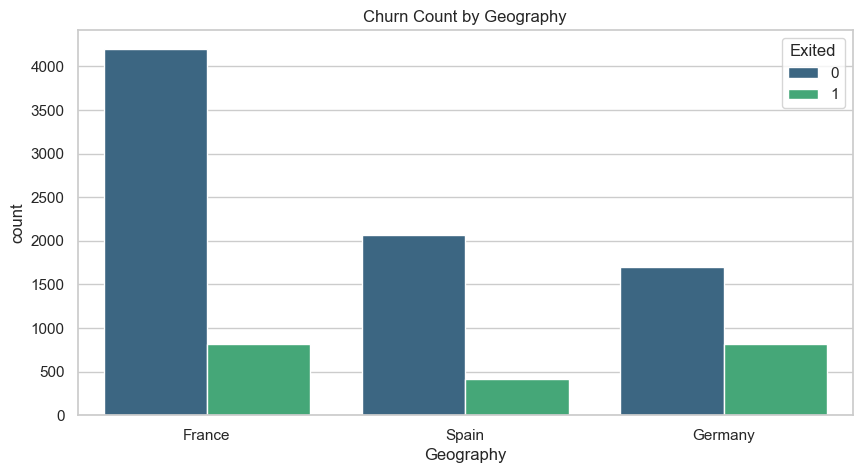

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x='Geography', hue='Exited', palette='viridis')
plt.title('Churn Count by Geography')
plt.show()

The analysis show:
- France has biggest customer base with very low churn rate.
- Spain does not has big customer base but churn rate is not too high.
- Germany has lowest customer base along with same churn rate as France, shows something wrong with Germany.

    Age Distribution by Churn (Stayed vs Exited)

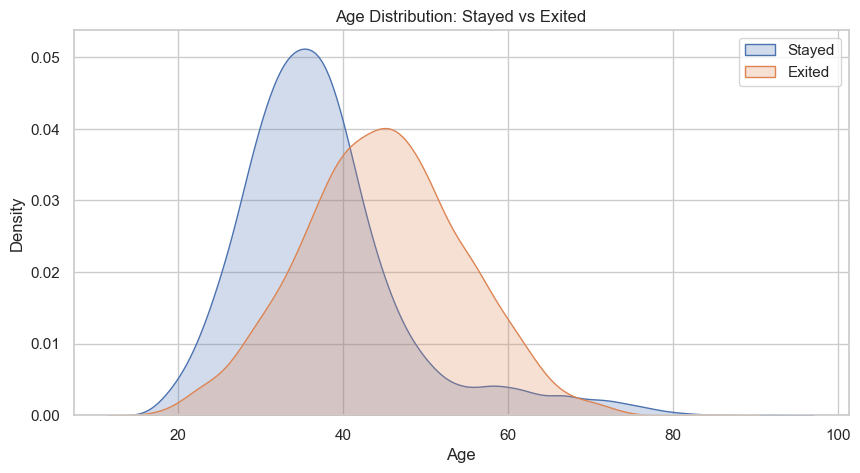

In [14]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data[data['Exited'] == 0]['Age'], label='Stayed', fill=True)
sns.kdeplot(data=data[data['Exited'] == 1]['Age'], label='Exited', fill=True)
plt.title('Age Distribution: Stayed vs Exited')
plt.legend()
plt.show()

This analysis shows:
- Young customers of age 20-35 are more likely to stay.
- Customers of age 35-55 are more likely to exit and this age particularly have more money.

    Balance vs churn rate

C:\Users\aksha\AppData\Local\Temp\ipykernel_6136\4037561699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Exited', y='Balance', ax=ax[1], palette='magma')


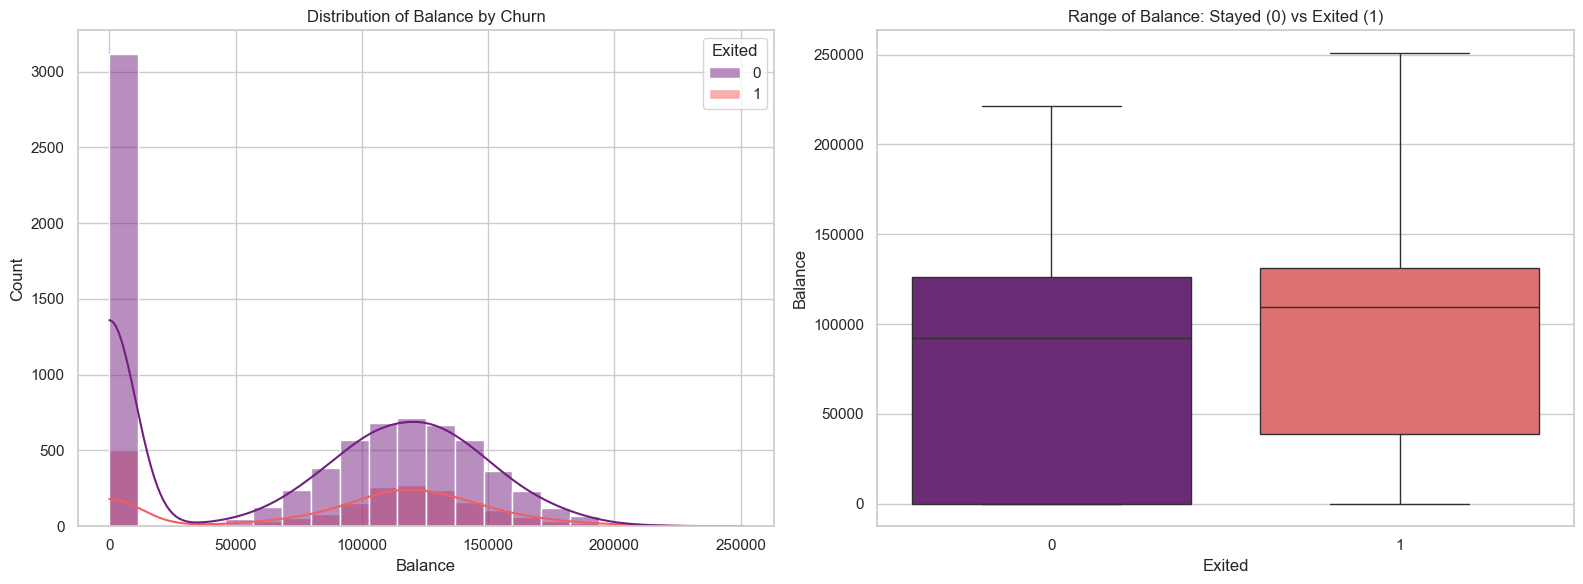

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution Plot (Showing the 0 balance spike)
sns.histplot(data=data, x='Balance', hue='Exited', kde=True, ax=ax[0], palette='magma')
ax[0].set_title('Distribution of Balance by Churn')

# 2. Box Plot (Showing the outliers and median)
sns.boxplot(data=data, x='Exited', y='Balance', ax=ax[1], palette='magma')
ax[1].set_title('Range of Balance: Stayed (0) vs Exited (1)')
plt.tight_layout()
plt.show()

1. The "Zero Balance" Segment is Loyal
You likely see a massive spike at the 0.0 mark on your histogram.

- Conclusion: Surprisingly, customers with a balance of $0 are actually less likely to churn than those with money in their accounts. This might be because these are "dormant" accounts that people just forget about, or they are basic accounts used for minor transactions.

2. High-Value Customers are Leaving
Look at the Box Plot (the one comparing Exited 0 and 1). You will notice that the "Exited" box is slightly higher or has a higher median line than the "Stayed" box.

- Conclusion: The bank is losing its wealthier customers. The average person who leaves has a higher balance than the average person who stays. This is a red flag for the bank’s revenue.

3. The "Danger Zone" ($100k - $150k)
In the histogram/KDE, look at the bell curve that happens after the zero spike.

- Conclusion: There is a high concentration of churned customers in the $100,000 to $150,000 range. This is the "Danger Zone." These are established customers with significant savings who are deciding to move their money elsewhere.

    Gender Analysis

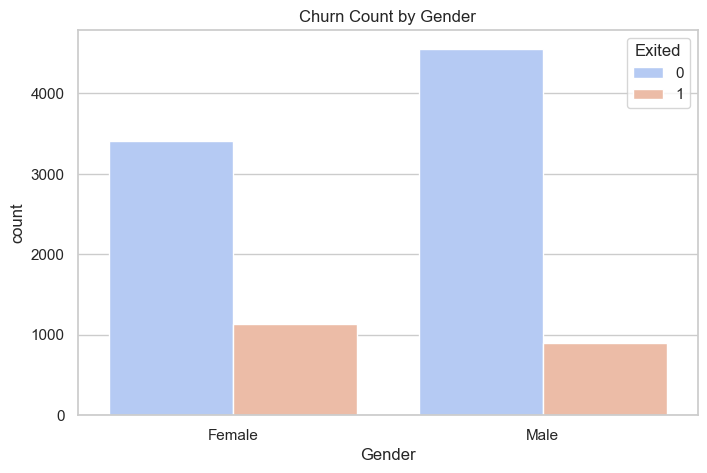

In [16]:
# Visualize the Count
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Gender', hue='Exited', palette='coolwarm')
plt.title('Churn Count by Gender')
plt.show()

- It shows there are more male customers in the bank.
- Also female are more likely to churn than male. 

--- Churn Rate by Gender ---
Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64


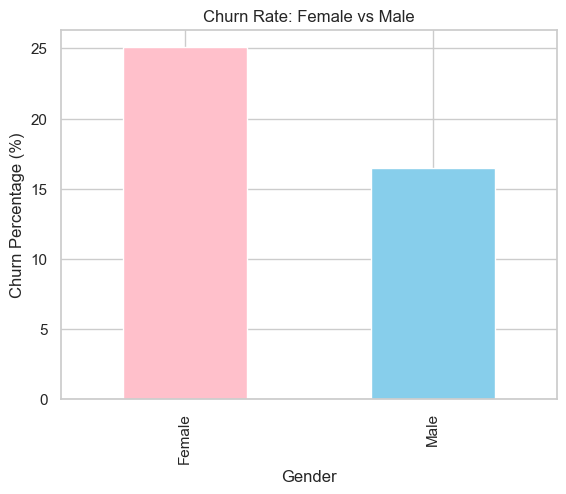

In [17]:
# Calculate the Churn Rate Percentage
gender_churn = data.groupby('Gender')['Exited'].mean() * 100
print("--- Churn Rate by Gender ---")
print(gender_churn)
# Quick Visual of the %
gender_churn.plot(kind='bar', color=['pink', 'skyblue'])
plt.ylabel('Churn Percentage (%)')
plt.title('Churn Rate: Female vs Male')
plt.show()

- Same as above female customers are leaving more than male customers.

    The Complaint-Churn Leakage (Complain vs Exited)

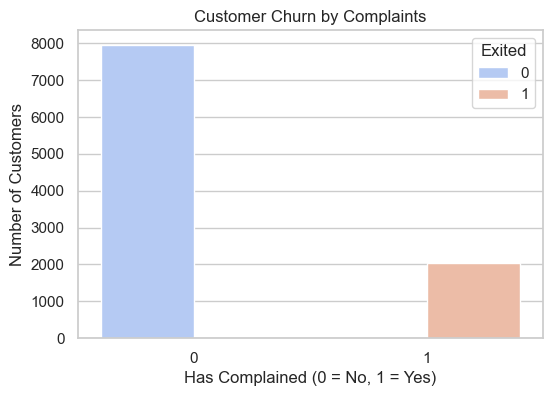

Exited,0,1
Complain,,
0,7952,4
1,10,2034


In [19]:
# Visualize Complaint vs Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Complain', hue='Exited', palette='coolwarm')
plt.title('Customer Churn by Complaints')
plt.xlabel('Has Complained (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

# Print cross-tabulation table
pd.crosstab(data['Complain'], data['Exited'])


- This analysis explain there is a higher chance of customer churn if complaints came.

    The Product Count Paradox (NumOfProducts vs Exited)

C:\Users\aksha\AppData\Local\Temp\ipykernel_6136\308905983.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='NumOfProducts', y='Exited', ci=None, palette='viridis')
C:\Users\aksha\AppData\Local\Temp\ipykernel_6136\308905983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='NumOfProducts', y='Exited', ci=None, palette='viridis')


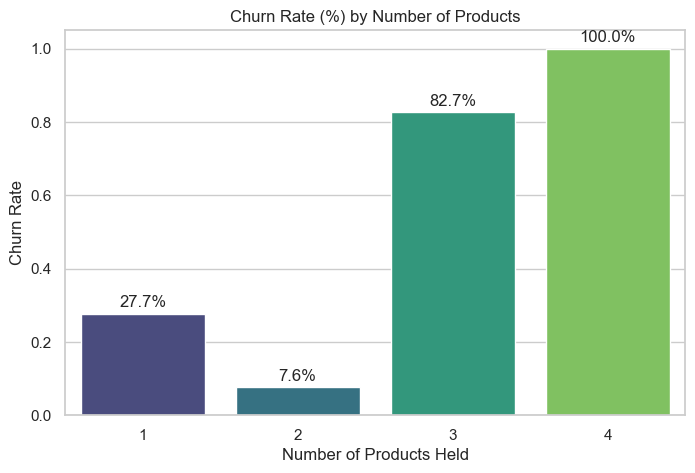

In [20]:
# Visualize Product count vs Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='NumOfProducts', y='Exited', ci=None, palette='viridis')
plt.title('Churn Rate (%) by Number of Products')
plt.xlabel('Number of Products Held')
plt.ylabel('Churn Rate')
# Display percentages on top of bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.show()


- This analysis shows forcing customers to use more products is not working (2 products is a sweet spot)

    Churn rate by Inactive by Active members

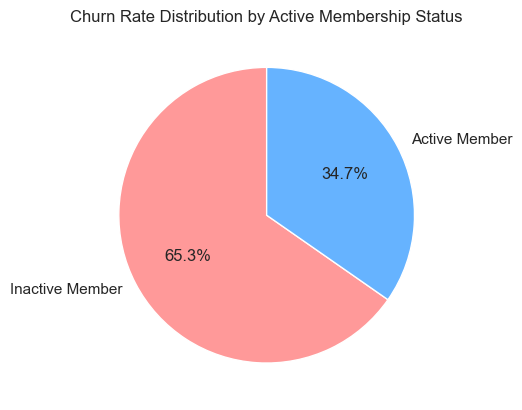

In [23]:
# Calculate churn rate for each group
churn_rate = data.groupby('IsActiveMember')['Exited'].mean()

# Visualize Active Status vs Churn using a Pie Chart
plt.pie(
    churn_rate, 
    labels=['Inactive Member', 'Active Member'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#ff9999', '#66b3ff']
)
plt.title('Churn Rate Distribution by Active Membership Status')
plt.show()

- It shows customers inactive are more likely to churn, but also shows active members have a good chance of churn

    The Satisfaction Score Paradox (Satisfaction Score vs Exited)

C:\Users\aksha\AppData\Local\Temp\ipykernel_6136\1954879678.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=data, x='Satisfaction Score', y='Exited', ci=None, palette='coolwarm')
C:\Users\aksha\AppData\Local\Temp\ipykernel_6136\1954879678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Satisfaction Score', y='Exited', ci=None, palette='coolwarm')


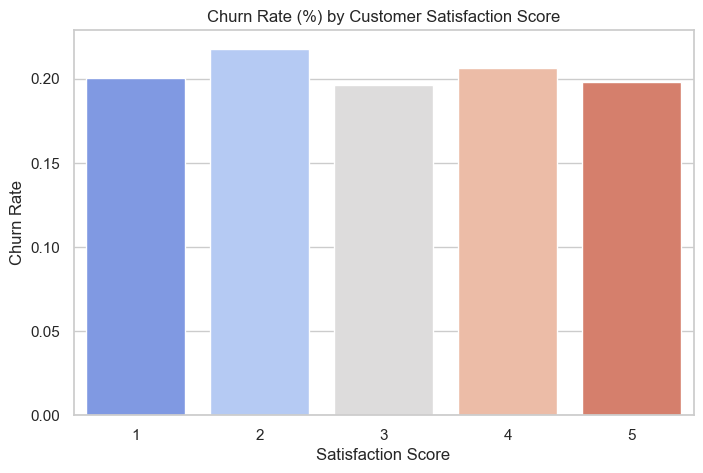

In [24]:
# Visualize Satisfaction Score vs Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x='Satisfaction Score', y='Exited', ci=None, palette='coolwarm')
plt.title('Churn Rate (%) by Customer Satisfaction Score')
plt.ylabel('Churn Rate')
plt.show()


- Doesn't look like customer churn is based on satisfaction score.

    Overall Feature Correlation Heatmap

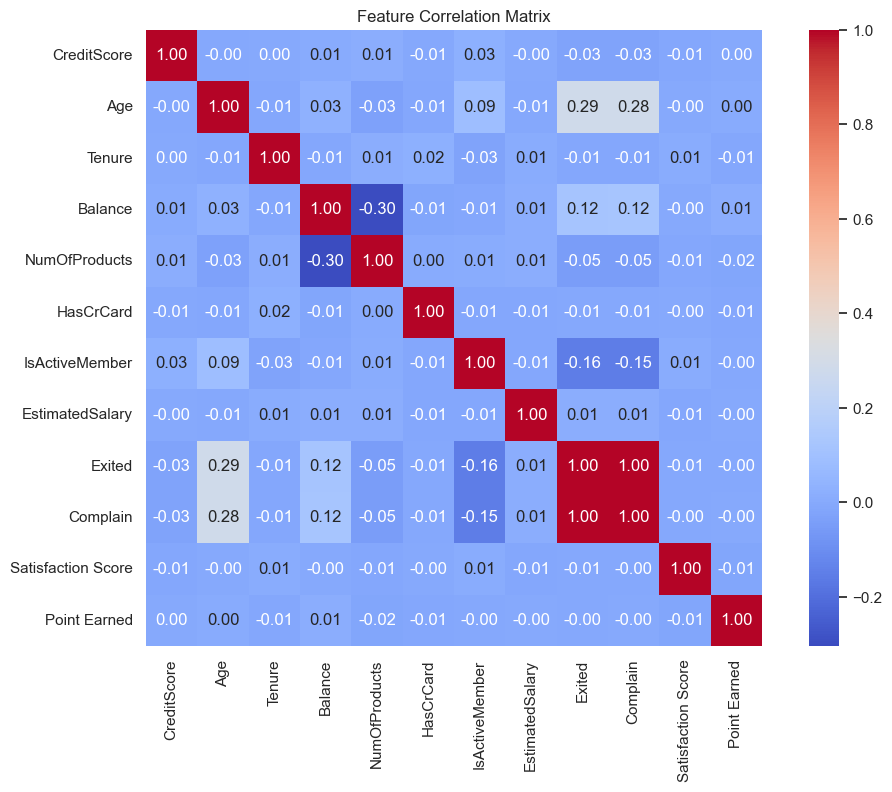

In [25]:
# Compute and plot correlation matrix
plt.figure(figsize=(12, 8))
numeric_data = data.select_dtypes(include=['number'])
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.show()


In [27]:
data.select_dtypes(include=['number']).corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,0.000077
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,0.002222
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.010196
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,0.014608
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,-0.015330
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,-0.011041
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,-0.004983
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,-0.001515
Exited,-0.026771,0.285296,-0.013656,0.118577,-0.047611,-0.006976,-0.156356,0.012490,1.000000,0.995693,-0.005849,-0.004628
Complain,-0.027048,0.283530,-0.013047,0.119124,-0.046357,-0.007095,-0.154741,0.012494,0.995693,1.000000,-0.004799,-0.002893


- So complaint has a high correlation with churn showing a customer complaints not resolved will most probably leave.

    But we can't use it in training purpose as model can see all other features are not important and giving important to only one variable